In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [21]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from src.text_processing import clean_text

from src.sentiment import (
    get_sentiment_score,
    get_sentiment_label
)

from src.thematic_analysis import (
    identify_theme
)

In [22]:
df = pd.read_csv(
    "../data/processed/bank_reviews_clean.csv"
)

df.head()

,review,rating,date,bank,source
0,Good,5,2026-05-16,CBE,Google Play
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play
2,worst,1,2026-05-16,CBE,Google Play
3,this app very full,5,2026-05-16,CBE,Google Play
4,good apps,4,2026-05-16,CBE,Google Play


In [23]:
print(df.shape)

print(df.columns)

df.info()

(1500, 5)
Index(['review', 'rating', 'date', 'bank', 'source'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1500 non-null   str  
 1   rating  1500 non-null   int64
 2   date    1500 non-null   str  
 3   bank    1500 non-null   str  
 4   source  1500 non-null   str  
dtypes: int64(1), str(4)
memory usage: 58.7 KB


In [24]:
df["clean_text"] = df[
    "review"
].apply(clean_text)

df.head()

,review,rating,date,bank,source,clean_text
0,Good,5,2026-05-16,CBE,Google Play,good
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,
2,worst,1,2026-05-16,CBE,Google Play,worst
3,this app very full,5,2026-05-16,CBE,Google Play,app full
4,good apps,4,2026-05-16,CBE,Google Play,good apps


In [25]:
df["sentiment_score"] = df[
    "review"
].apply(get_sentiment_score)

df.head()

,review,rating,date,bank,source,clean_text,sentiment_score
0,Good,5,2026-05-16,CBE,Google Play,good,0.4404
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,0.0000
2,worst,1,2026-05-16,CBE,Google Play,worst,-0.6249
3,this app very full,5,2026-05-16,CBE,Google Play,app full,0.0000
4,good apps,4,2026-05-16,CBE,Google Play,good apps,0.4404


In [26]:
df["sentiment_label"] = df[
    "sentiment_score"
].apply(get_sentiment_label)

df.head()

,review,rating,date,bank,source,clean_text,sentiment_score,sentiment_label
0,Good,5,2026-05-16,CBE,Google Play,good,0.4404,positive
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,0.0000,neutral
2,worst,1,2026-05-16,CBE,Google Play,worst,-0.6249,negative
3,this app very full,5,2026-05-16,CBE,Google Play,app full,0.0000,neutral
4,good apps,4,2026-05-16,CBE,Google Play,good apps,0.4404,positive


In [27]:
df["sentiment_label"].value_counts()

sentiment_label
positive    911
neutral     387
negative    202
Name: count, dtype: int64

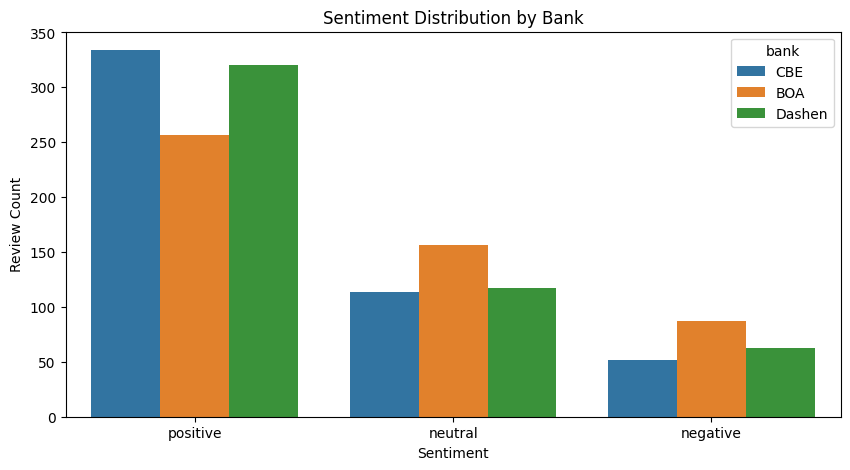

In [28]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="sentiment_label",
    hue="bank"
)

plt.title(
    "Sentiment Distribution by Bank"
)

plt.xlabel("Sentiment")

plt.ylabel("Review Count")

plt.show()

In [29]:
tfidf = TfidfVectorizer(
    max_features=20
)

X = tfidf.fit_transform(
    df["clean_text"]
)

keywords = tfidf.get_feature_names_out()

print(keywords)

['app' 'bank' 'banking' 'best' 'dashen' 'easy' 'even' 'fast' 'fix' 'good'
 'like' 'mobile' 'nice' 'please' 'time' 'update' 'use' 'work' 'working'
 'worst']


In [30]:
df["identified_theme"] = df[
    "review"
].apply(identify_theme)

df.head()

,review,rating,date,bank,source,clean_text,sentiment_score,sentiment_label,identified_theme
0,Good,5,2026-05-16,CBE,Google Play,good,0.4404,positive,Other
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,0.0000,neutral,Other
2,worst,1,2026-05-16,CBE,Google Play,worst,-0.6249,negative,Other
3,this app very full,5,2026-05-16,CBE,Google Play,app full,0.0000,neutral,Other
4,good apps,4,2026-05-16,CBE,Google Play,good apps,0.4404,positive,Other


In [31]:
df["identified_theme"].value_counts()

identified_theme
Other                      1241
Transaction Performance      94
User Experience              73
Account Access Issues        48
Customer Support             44
Name: count, dtype: int64

In [32]:
bank_sentiment = df.groupby(
    "bank"
)["sentiment_score"].mean()

bank_sentiment

bank
BOA       0.172083
CBE       0.277551
Dashen    0.291102
Name: sentiment_score, dtype: float64

In [33]:
final_df = df[
    [
        "review",
        "rating",
        "bank",
        "sentiment_label",
        "sentiment_score",
        "identified_theme"
    ]
]

final_df.head()

,review,rating,bank,sentiment_label,sentiment_score,identified_theme
0,Good,5,CBE,positive,0.4404,Other
1,🤙🏼🤙🏼,5,CBE,neutral,0.0000,Other
2,worst,1,CBE,negative,-0.6249,Other
3,this app very full,5,CBE,neutral,0.0000,Other
4,good apps,4,CBE,positive,0.4404,Other


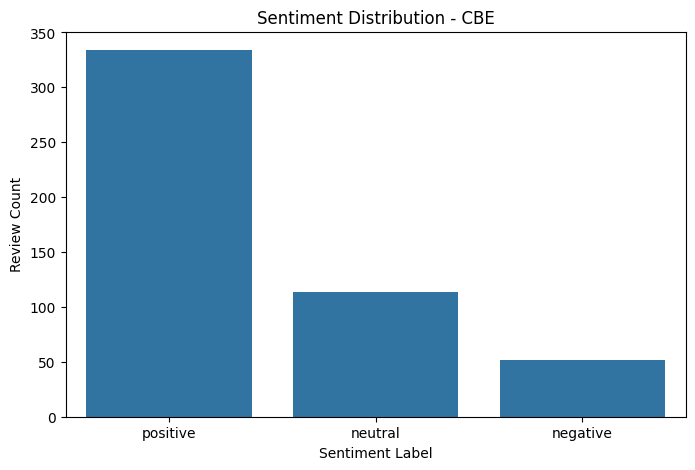

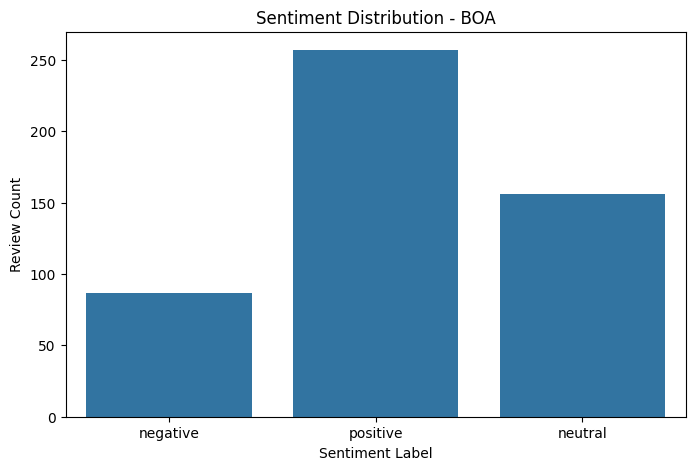

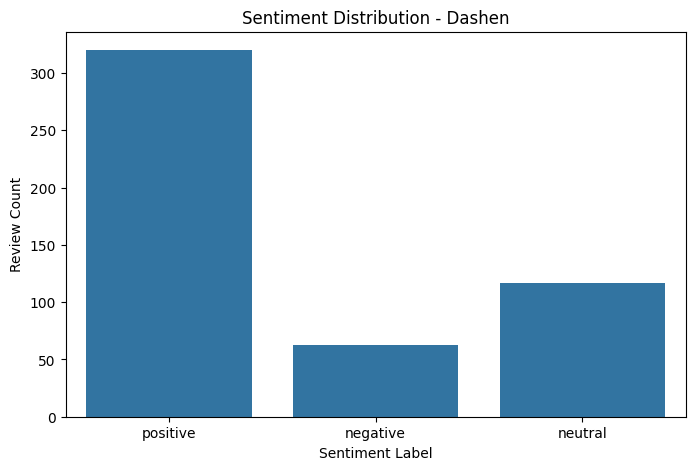

In [34]:
banks = df["bank"].unique()

for bank in banks:

    plt.figure(figsize=(8, 5))

    bank_df = df[
        df["bank"] == bank
    ]

    sns.countplot(
        data=bank_df,
        x="sentiment_label"
    )

    plt.title(
        f"Sentiment Distribution - {bank}"
    )

    plt.xlabel("Sentiment Label")

    plt.ylabel("Review Count")

    plt.show()

In [35]:
final_df.to_csv(
    "../data/processed/task2_sentiment_analysis.csv",
    index=False
)

print("Task 2 results saved.")

Task 2 results saved.


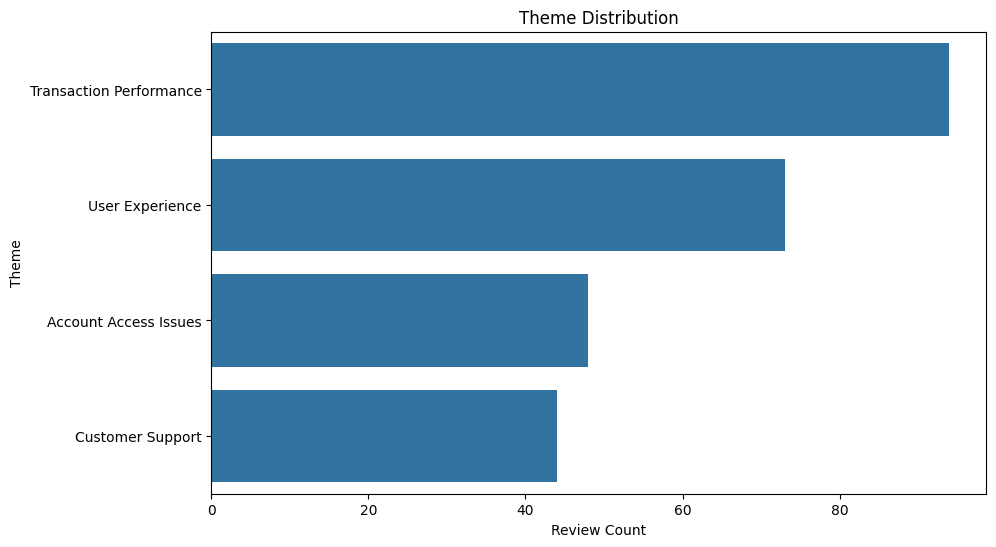

In [36]:
theme_df = df[
    df["identified_theme"] != "Other"
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=theme_df,
    y="identified_theme",
    order=theme_df[
        "identified_theme"
    ].value_counts().index
)

plt.title("Theme Distribution")

plt.xlabel("Review Count")

plt.ylabel("Theme")

plt.show()

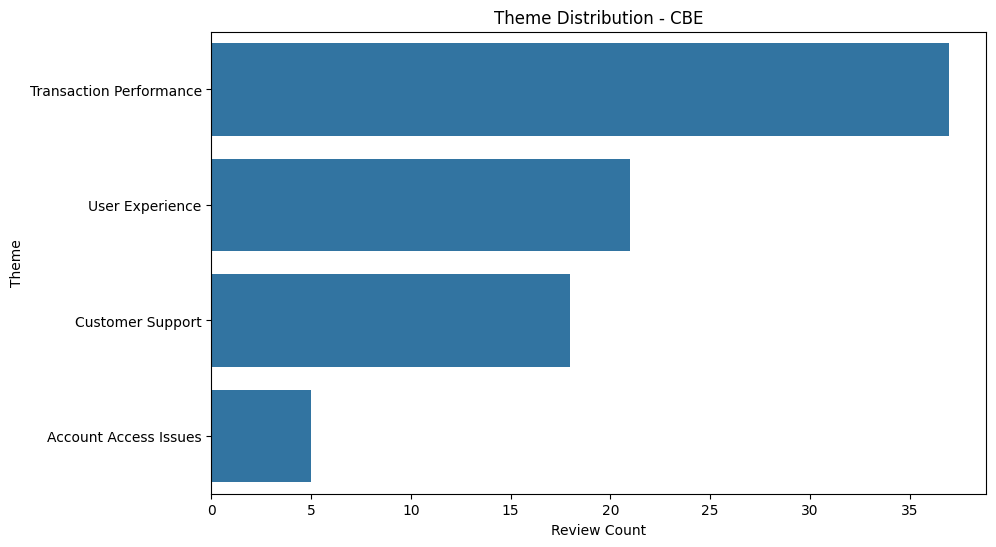

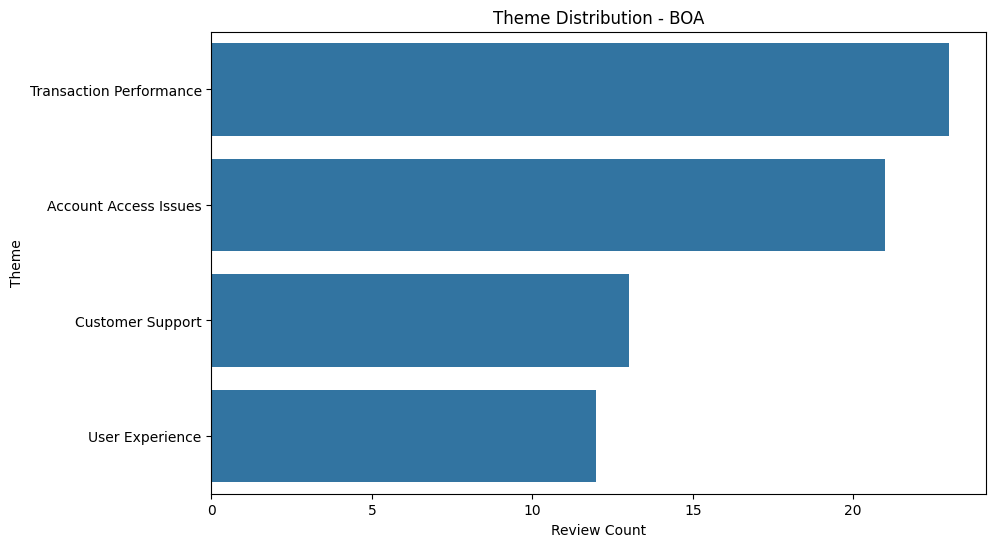

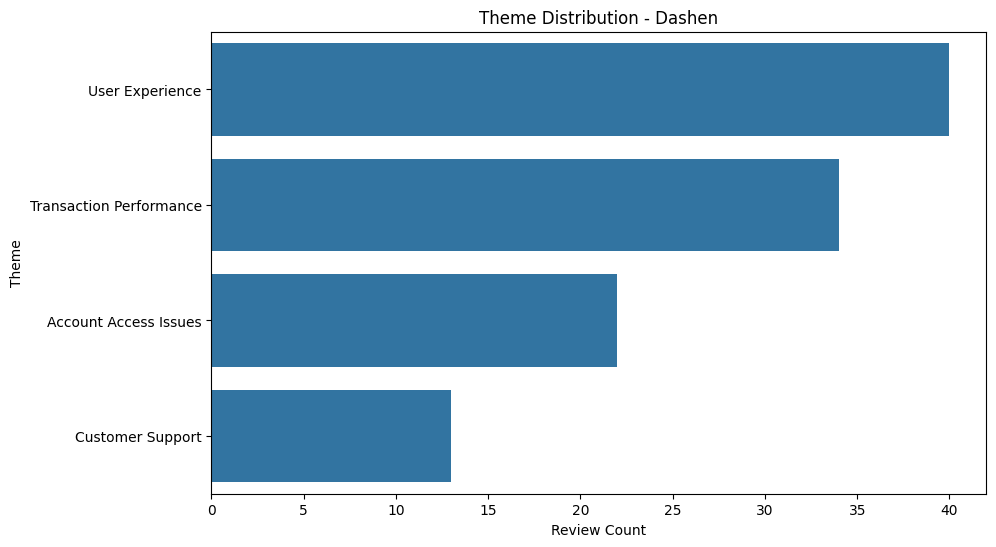

In [37]:
banks = df["bank"].unique()

for bank in banks:

    bank_df = df[
        (df["bank"] == bank) &
        (df["identified_theme"] != "Other")
    ]

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=bank_df,
        y="identified_theme",
        order=bank_df[
            "identified_theme"
        ].value_counts().index
    )

    plt.title(
        f"Theme Distribution - {bank}"
    )

    plt.xlabel("Review Count")

    plt.ylabel("Theme")

    plt.show()

In [39]:
df["clean_review"] = df[
    "review"
].apply(clean_text)

df.head()

,review,rating,date,bank,source,clean_text,sentiment_score,sentiment_label,identified_theme,clean_review
0,Good,5,2026-05-16,CBE,Google Play,good,0.4404,positive,Other,good
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,0.0000,neutral,Other,
2,worst,1,2026-05-16,CBE,Google Play,worst,-0.6249,negative,Other,worst
3,this app very full,5,2026-05-16,CBE,Google Play,app full,0.0000,neutral,Other,app full
4,good apps,4,2026-05-16,CBE,Google Play,good apps,0.4404,positive,Other,good apps


In [41]:
df["identified_theme"] = df[
    "clean_review"
].apply(identify_theme)

df.head()

,review,rating,date,bank,source,clean_text,sentiment_score,sentiment_label,identified_theme,clean_review
0,Good,5,2026-05-16,CBE,Google Play,good,0.4404,positive,Other,good
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,0.0000,neutral,Other,
2,worst,1,2026-05-16,CBE,Google Play,worst,-0.6249,negative,Other,worst
3,this app very full,5,2026-05-16,CBE,Google Play,app full,0.0000,neutral,Other,app full
4,good apps,4,2026-05-16,CBE,Google Play,good apps,0.4404,positive,Other,good apps
